# 18장 실습 — 잊는다

17장의 플라이휠이 한 바퀴 돌았다. 현장 데이터가 정책을 고쳤다. 그 바퀴가 계속 돌면 정책은 계속 나아지는가.

계속 배우는 시스템에는 오래된 문제가 있다. **새로 배우면 예전 것을 잊는다.** 신경망의 파국적 망각(catastrophic forgetting)이고, 연속 학습 연구의 절반이 이 하나를 붙들고 있다.

이 주제를 다루기 전에 적어 둘 것이 있다. **로봇 정책의 연속 학습에는 믿을 만한 정량 결과가 드물다.** 기준선이라 할 것은 LIBERO 가 제안한 전후 전이 지표 정도이고, 이 책이 인용할 만한 숫자는 앞 장들처럼 쌓여 있지 않다. 그러니 이 노트북은 **문헌을 재현하는 대신 현상을 직접 만들어 재고**, 마지막에 열린 자리를 열린 채로 남긴다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (65s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 두 과제

같은 로봇, 같은 물체, 목표만 다르다.

- **A 오른쪽** — 블록을 +x 로 0.30 m 민다. 이 책이 열일곱 장 동안 쓴 과제다
- **B 위쪽** — 블록을 +y 로 0.30 m 민다

밀대는 두 과제 모두 **목표의 반대쪽 0.09 m 뒤**에서 출발한다. 그러니 두 과제는 **회전만 다르고 물리적으로 똑같다.** 바닥도 구동기도 방향에 대칭이므로 난이도가 같고, 관측은 상대 좌표라 값의 범위도 같다.

이 설계가 중요하다. B 가 더 어려워서 성적이 떨어지는 것이 아님을 보장해 준다. **똑같이 어려운 과제를 방향만 돌려 놓았을 때 무슨 일이 생기는가**가 이 노트북의 질문이다.

In [6]:
GOALS = {"A 오른쪽": np.array([.30, 0.]),
         "B 위쪽": np.array([0., .30])}


class Task(Vec):
    """목표 방향만 다른 과제 — pa 를 주면 판마다 섞는다"""

    def __init__(self, n, seed=0, goal="A 오른쪽", pa=None):
        self.goal = goal
        self.pa = pa          # A 과제의 비율 (None 이면 goal 고정)
        super().__init__(n, seed)

    def reset(self, i):
        super().reset(i)
        d = self.d[i]
        k = self.goal
        if self.pa is not None:
            k = ("A 오른쪽" if self.rng.random() < self.pa
                 else "B 위쪽")
        self.g[i] = GOALS[k] + self.rng.uniform(-.04, .04, 2)
        b = np.asarray(d.qpos[0:2], float)
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])


print("과제:", " · ".join(GOALS))

과제: A 오른쪽 · B 위쪽


In [7]:
def train_on(make_env, init=None, budget=250_000, seed=0,
             n=16, T=32, lr=3e-3, anc=None, aw=0.):
    """anc 를 주면 그 기록을 되새기며(리허설) 학습한다"""
    torch.manual_seed(seed)
    env = make_env()
    ac = copy.deepcopy(init) if init is not None else AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                if aw:
                    q = torch.randint(0, len(anc[0]), (256,))
                    loss = loss + aw * ((ac.pi(anc[0][q])
                                         - anc[1][q]) ** 2).mean()
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


def score(policy, goal, n=150, reps=2, seed=999):
    torch.manual_seed(seed)
    env = Task(n, seed, goal=goal)
    ok = done = 0
    for t in range(EP * reps):
        ot = torch.from_numpy(env.obs())
        with torch.no_grad():
            a = policy.dist(ot).sample().numpy()
        _, dn, sc = env.step(a)
        for v in sc:
            ok += int(v > .5)
            done += 1
    return ok, done


PI_A = POLICY          # 이 책이 열일곱 장 동안 쓴 그 정책이다
t0 = time.time()
a = score(PI_A, "A 오른쪽")
b = score(PI_A, "B 위쪽")
print(f"πA — A {a[0] / a[1]:.2f} · B {b[0] / b[1]:.2f}"
      f"  ({time.time() - t0:.0f}s)")

πA — A 0.82 · B 0.00  (8s)


## 새 과제를 이어서 배운다

πA 에서 출발해 **B 만으로** 이어 학습한다. 실기의 상황으로 옮기면 새 작업장, 새 부품, 새 자세다 — 예전 과제의 데이터는 이미 없다.

예산은 처음 학습과 같게 둔다. 비교선으로 **맨바닥에서 같은 예산으로 B 만 배운 정책**을 둔다. 두 과제의 난이도가 같으므로 이 비교선은 「이 예산이면 B 를 배울 수 있다」는 사실을 보장해 준다.

In [8]:
BUD2 = 250_000
t0 = time.time()
PI_B0 = train_on(lambda: Task(16, 1, goal="B 위쪽"), budget=BUD2)
print(f"B 맨바닥 끝  ({time.time() - t0:.0f}s)")
PI_AB = train_on(lambda: Task(16, 1, goal="B 위쪽"),
                 init=PI_A, budget=BUD2)
print(f"A→B 끝  ({time.time() - t0:.0f}s)")

B 맨바닥 끝  (65s)


A→B 끝  (131s)


In [9]:
def table(rows):
    print(pad("정책", 16) + pad("A 오른쪽", 12, True)
          + pad("B 위쪽", 12, True) + pad("A 95% 구간", 18, True))
    for k, p in rows.items():
        a, b = score(p, "A 오른쪽"), score(p, "B 위쪽")
        lo, hi = wilson(*a)
        print(pad(k, 16) + pad(f"{a[0] / a[1]:.2f}", 12, True)
              + pad(f"{b[0] / b[1]:.2f}", 12, True)
              + pad(f"[{lo:.2f}, {hi:.2f}]", 18, True))


t0 = time.time()
table({"πA (A만)": PI_A, "πB (맨바닥)": PI_B0, "πA→B (B만)": PI_AB})
print()
print(f"과제마다 300 판 · 명목 조건  ({time.time() - t0:.0f}s)")

정책                A 오른쪽      B 위쪽        A 95% 구간


πA (A만)                0.82        0.00      [0.78, 0.86]


πB (맨바닥)             0.00        0.73      [0.00, 0.01]


πA→B (B만)              0.00        0.99      [0.00, 0.01]

과제마다 300 판 · 명목 조건  (25s)



## 이어 학습은 빠르고 비싸다

나머지 두 줄은 한 쌍으로 읽는다.

**빠르다.** πA 에서 출발한 쪽이 맨바닥보다 B 를 더 잘 배웠다. 같은 예산인데 성적이 높다 — 밀기라는 기술 자체는 옮겨 간 것이다. 순방향 전이가 있다.

**비싸다.** 그 대가로 A 가 0.82 에서 **0.00** 이 됐다. 조금 깎인 것이 아니라 전부 사라졌다. 파국적 망각이라는 이름이 과장이 아니다.

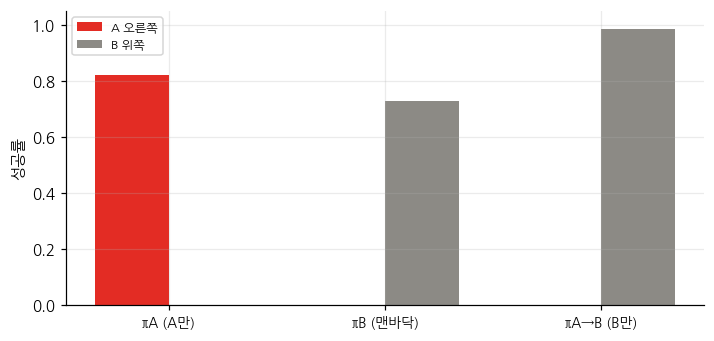

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ks = ["πA (A만)", "πB (맨바닥)", "πA→B (B만)"]
ps = [PI_A, PI_B0, PI_AB]
x = np.arange(len(ks))
w = .34
SC = {k: (score(p, "A 오른쪽"), score(p, "B 위쪽"))
      for k, p in zip(ks, ps)}
for i, (t, col) in enumerate((("A 오른쪽", RED), ("B 위쪽", GREY))):
    v = [SC[k][i][0] / SC[k][i][1] for k in ks]
    ax.bar(x + (i - .5) * w, v, w, color=col, label=t)
ax.set_xticks(x)
ax.set_xticklabels(ks, fontsize=9)
ax.set_ylabel("성공률")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 로그를 되새긴다

망각을 막는 가장 단순한 방법은 **예전 과제를 계속 보여 주는 것**이다. 예전 과제의 환경을 다시 돌릴 수 있다면 판을 섞으면 되지만, 실기에서는 그 작업장이 이미 없다.

남아 있는 것은 **기록**이다. 16장에서 판마다 적어 둔 그 로그다. 관측과 그때 낸 명령의 쌍이 남아 있으면, 환경 없이도 예전 행동을 되새길 수 있다.

B 를 강화학습으로 배우면서, 동시에 **A 의 기록을 행동 복제로 붙잡는다.** 붙잡는 세기를 훑는다.

In [11]:
def collect_log(policy, goal, n=64, steps=300, seed=9):
    """예전 과제의 로그 — 관측과 그때 낸 명령"""
    torch.manual_seed(seed)
    env = Task(n, seed, goal=goal)
    O = []
    for t in range(steps):
        o = env.obs()
        O.append(o)
        with torch.no_grad():
            a = policy.dist(torch.from_numpy(o)).sample().numpy()
        env.step(a)
    O = np.concatenate(O)
    with torch.no_grad():
        A = policy.pi(torch.from_numpy(O)).numpy()
    return torch.from_numpy(O), torch.from_numpy(A)


LOG_A = collect_log(PI_A, "A 오른쪽")
print(f"A 과제 로그 {len(LOG_A[0]):,} 스텝")

A 과제 로그 19,200 스텝


In [12]:
AW = (0., .03, .1, .3, 3.)
t0 = time.time()
REH = {0.: PI_AB}
for aw in AW[1:]:
    REH[aw] = train_on(lambda: Task(16, 1, goal="B 위쪽"),
                       init=PI_A, budget=BUD2,
                       anc=LOG_A, aw=aw)
    print(f"되새김 세기 {aw} 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("되새김 세기", 13) + pad("A 오른쪽", 12, True)
      + pad("B 위쪽", 12, True) + pad("둘의 평균", 12, True))
CUR = {}
for aw in AW:
    a, b = score(REH[aw], "A 오른쪽"), score(REH[aw], "B 위쪽")
    ra, rb = a[0] / a[1], b[0] / b[1]
    CUR[aw] = (ra, rb)
    print(pad(f"{aw}", 13) + pad(f"{ra:.2f}", 12, True)
          + pad(f"{rb:.2f}", 12, True)
          + pad(f"{(ra + rb) / 2:.2f}", 12, True))
print()
base_a = score(PI_A, "A 오른쪽")
print(f"이어 학습 전 A 성적 — {base_a[0] / base_a[1]:.2f}")

되새김 세기 0.03 끝  (71s)


되새김 세기 0.1 끝  (141s)


되새김 세기 0.3 끝  (213s)


되새김 세기 3.0 끝  (282s)

되새김 세기      A 오른쪽      B 위쪽   둘의 평균


0.0                  0.00        0.99        0.49


0.03                 0.12        0.81        0.46


0.1                  0.59        0.01        0.30


0.3                  0.76        0.00        0.38


3.0                  0.78        0.05        0.41



이어 학습 전 A 성적 — 0.82


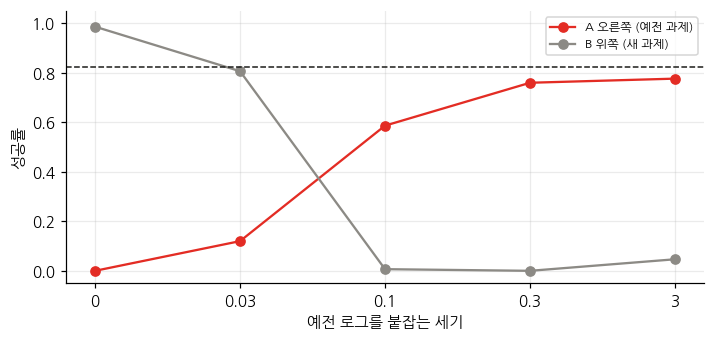

In [13]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
xs = np.arange(len(AW))
ax.plot(xs, [CUR[a][0] for a in AW], "-o", color=RED,
        label="A 오른쪽 (예전 과제)")
ax.plot(xs, [CUR[a][1] for a in AW], "-o", color=GREY,
        label="B 위쪽 (새 과제)")
ax.axhline(base_a[0] / base_a[1], ls="--", lw=1, color=INK)
ax.set_xticks(xs)
ax.set_xticklabels([f"{a:g}" for a in AW])
ax.set_xlabel("예전 로그를 붙잡는 세기")
ax.set_ylabel("성공률")
ax.set_ylim(-.05, 1.05)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 정리

**대칭이 있어도 정책이 그 대칭을 배우지는 않는다.** 두 과제는 회전만 다르고 물리적으로 같은데, A 를 배운 정책의 B 성적이 0 이었다. 관측을 상대 좌표로 적는 것만으로 일반화가 생기지 않는다.

**이어 학습은 빠르다.** πA 에서 출발한 쪽이 맨바닥보다 B 를 잘 배웠다(0.99 대 0.73). 밀기라는 기술 자체는 옮겨 간다.

**그리고 비싸다.** A 가 0.82 에서 0.00 이 됐다. 조금 깎인 것이 아니라 전부 사라졌다.

**예전 로그를 되새기면 붙잡힌다.** 환경을 다시 돌릴 필요 없이 관측과 명령의 쌍만 있으면 된다. 16장에서 세운 로그 스키마가 여기서 다시 값을 한다 — 게이트를 위해 남긴 로그가 망각을 막는 데도 쓰인다.

**그런데 맞바꿈이 곡선이 아니라 절벽이다.** 세기를 0.03 에서 3 까지 백 배로 훑었는데, 전환이 0.03 과 0.1 사이에서 일어난다. 0.03 에서 A 0.12 · B 0.81 이고 0.1 에서 A 0.59 · B 0.01 이다. **둘을 함께 지키는 자리를 찾지 못했다.**

이것이 연속 학습이 어려운 이유의 축소판이다. 손잡이는 있는데 그 손잡이에 중간 지점이 없다.

**그리고 열린 자리를 열린 채로 닫는다.** 이 실습이 만든 것은 목표 방향 하나만 바뀐 두 과제다. 실기의 연속 학습은 이보다 훨씬 거칠다 — 물체가 바뀌고, 조명이 바뀌고, 로봇이 바뀐다. 그 조건에서 되새김이 얼마나 듣는지, 무엇을 얼마나 남겨 두어야 하는지에 대해 **이 책이 인용할 만한 정량 결과는 아직 없다.** 3권이 월드 모델의 한계를 적고 닫았듯, 4권도 여기서 닫는다.

이 책의 열여덟 장이 한 일은 하나다. **제때 도착하지 못한 좋은 명령은 좋은 명령이 아니다.** 나머지는 그 문장을 재는 법과, 재서 알게 된 것들이었다.